In [1]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

uploaded = files.upload()

# Load baseline values
baseline_raw = pd.read_csv('Final Project Baseline Values.csv', header=None)
print("── Baseline Values ──")
print(baseline_raw)

# Load control and experiment results
control    = pd.read_csv('Final Project Results - Control.csv')
experiment = pd.read_csv('Final Project Results - Experiment.csv')

print("\n── Control (first 5 rows) ──")
print(control.head())
print("\nShape:", control.shape)

print("\n── Experiment (first 5 rows) ──")
print(experiment.head())
print("\nShape:", experiment.shape)

Saving Final Project Results - Experiment.csv to Final Project Results - Experiment (1).csv
Saving Final Project Results - Control.csv to Final Project Results - Control (1).csv
Saving Final Project Baseline Values.csv to Final Project Baseline Values (1).csv
── Baseline Values ──
                                                   0             1
0  Unique cookies to view course overview page pe...  40000.000000
1  Unique cookies to click "Start free trial" per...   3200.000000
2                               Enrollments per day:    660.000000
3   Click-through-probability on "Start free trial":      0.080000
4             Probability of enrolling, given click:      0.206250
5              Probability of payment, given enroll:      0.530000
6                Probability of payment, given click      0.109313

── Control (first 5 rows) ──
          Date  Pageviews  Clicks  Enrollments  Payments
0  Sat, Oct 11       7723     687        134.0      70.0
1  Sun, Oct 12       9102     779     

In [2]:
# Parse baseline into a clean dictionary
baseline = {
    'daily_pageviews'       : 40000,
    'daily_clicks'          : 3200,
    'daily_enrollments'     : 660,
    'ctr'                   : 0.08,
    'enrollment_rate'       : 0.20625,
    'payment_rate_enroll'   : 0.53,
    'payment_rate_click'    : 0.109313,
}

print("══════════════════════════════════════════════════════")
print("  EXPERIMENT: Udacity Free-Trial Screener")
print("══════════════════════════════════════════════════════")
print()
print("HYPOTHESIS")
print("  H0 (null):  The screener has no effect on enrollment")
print("              or payment rates.")
print("  H1 (alt):   The screener reduces enrollments but")
print("              increases or maintains payment rate —")
print("              filtering low-intent students.")
print()
print("METRICS")
print()
print("  Invariant metrics (should NOT change between groups):")
print("  • Pageviews     — randomization unit, must be balanced")
print("  • Clicks        — happen before screener is shown")
print()
print("  Evaluation metrics (what we're testing):")
print("  • Gross Conversion = Enrollments / Clicks")
print("    Goal: DECREASE (fewer low-intent enrollments)")
print()
print("  • Net Conversion   = Payments / Clicks")
print("    Goal: NO significant decrease (revenue protected)")
print()
print("SIGNIFICANCE THRESHOLD")
print("  Alpha = 0.05 (95% confidence)")
print("  We need BOTH metrics to move in the right direction")
print("  to recommend launch.")
print()
print("BASELINE RATES")
print(f"  Gross Conversion baseline: {baseline['enrollment_rate']:.4f} ({baseline['enrollment_rate']*100:.2f}%)")
print(f"  Net Conversion baseline:   {baseline['payment_rate_click']:.4f} ({baseline['payment_rate_click']*100:.2f}%)")
print("══════════════════════════════════════════════════════")

══════════════════════════════════════════════════════
  EXPERIMENT: Udacity Free-Trial Screener
══════════════════════════════════════════════════════

HYPOTHESIS
  H0 (null):  The screener has no effect on enrollment
              or payment rates.
  H1 (alt):   The screener reduces enrollments but
              increases or maintains payment rate —
              filtering low-intent students.

METRICS

  Invariant metrics (should NOT change between groups):
  • Pageviews     — randomization unit, must be balanced
  • Clicks        — happen before screener is shown

  Evaluation metrics (what we're testing):
  • Gross Conversion = Enrollments / Clicks
    Goal: DECREASE (fewer low-intent enrollments)

  • Net Conversion   = Payments / Clicks
    Goal: NO significant decrease (revenue protected)

SIGNIFICANCE THRESHOLD
  Alpha = 0.05 (95% confidence)
  We need BOTH metrics to move in the right direction
  to recommend launch.

BASELINE RATES
  Gross Conversion baseline: 0.2062 (20.62%

In [3]:
#Step 3: Sanity Checks

def sanity_check(control_val, experiment_val, metric_name, expected_split=0.5):
    total = control_val + experiment_val
    observed_split = control_val / total

    # Standard error for a proportion
    se = np.sqrt(expected_split * (1 - expected_split) / total)

    # 95% confidence interval around expected 0.5 split
    ci_lower = expected_split - 1.96 * se
    ci_upper = expected_split + 1.96 * se

    passed = ci_lower <= observed_split <= ci_upper

    print(f"── {metric_name} ──")
    print(f"  Control:          {control_val:,}")
    print(f"  Experiment:       {experiment_val:,}")
    print(f"  Total:            {total:,}")
    print(f"  Observed split:   {observed_split:.4f} ({observed_split*100:.2f}%)")
    print(f"  Expected split:   {expected_split:.4f} (50.00%)")
    print(f"  95% CI:           [{ci_lower:.4f}, {ci_upper:.4f}]")
    print(f"  Result:           {'✅ PASSED — randomization looks good' if passed else '❌ FAILED — randomization issue!'}")
    print()
    return passed

# Total pageviews and clicks across all 37 days
total_pageviews_control    = control['Pageviews'].sum()
total_pageviews_experiment = experiment['Pageviews'].sum()

total_clicks_control       = control['Clicks'].sum()
total_clicks_experiment    = experiment['Clicks'].sum()

print("══════════════════════════════════════════════════════")
print("  SANITY CHECKS — Invariant Metric Validation")
print("══════════════════════════════════════════════════════\n")

pv_passed = sanity_check(total_pageviews_control, total_pageviews_experiment, "Pageviews")
cl_passed = sanity_check(total_clicks_control,    total_clicks_experiment,    "Clicks")

if pv_passed and cl_passed:
    print("✅ ALL SANITY CHECKS PASSED")
    print("   Randomization is valid. Safe to proceed to results analysis.")
else:
    print("❌ SANITY CHECK FAILED")
    print("   Do NOT proceed — experiment data may be corrupted.")

══════════════════════════════════════════════════════
  SANITY CHECKS — Invariant Metric Validation
══════════════════════════════════════════════════════

── Pageviews ──
  Control:          345,543
  Experiment:       344,660
  Total:            690,203
  Observed split:   0.5006 (50.06%)
  Expected split:   0.5000 (50.00%)
  95% CI:           [0.4988, 0.5012]
  Result:           ✅ PASSED — randomization looks good

── Clicks ──
  Control:          28,378
  Experiment:       28,325
  Total:            56,703
  Observed split:   0.5005 (50.05%)
  Expected split:   0.5000 (50.00%)
  95% CI:           [0.4959, 0.5041]
  Result:           ✅ PASSED — randomization looks good

✅ ALL SANITY CHECKS PASSED
   Randomization is valid. Safe to proceed to results analysis.


In [4]:
#Step 4: Statistical Analysis

def analyze_metric(control_num, control_denom, exp_num, exp_denom, metric_name, goal):

    # Rates
    control_rate = control_num / control_denom
    exp_rate     = exp_num / exp_denom
    observed_diff = exp_rate - control_rate

    # Pooled standard error (two-proportion z-test)
    pooled_p = (control_num + exp_num) / (control_denom + exp_denom)
    se = np.sqrt(pooled_p * (1 - pooled_p) * (1/control_denom + 1/exp_denom))

    # Z-score and p-value
    z_score = observed_diff / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

    # 95% Confidence interval
    ci_lower = observed_diff - 1.96 * se
    ci_upper = observed_diff + 1.96 * se

    # Significance
    significant = p_value < 0.05

    print(f"── {metric_name} ──")
    print(f"  Control rate:     {control_rate:.4f} ({control_rate*100:.2f}%)")
    print(f"  Experiment rate:  {exp_rate:.4f} ({exp_rate*100:.2f}%)")
    print(f"  Observed diff:    {observed_diff:+.4f} ({observed_diff*100:+.2f}pp)")
    print(f"  95% CI:           [{ci_lower:.4f}, {ci_upper:.4f}]")
    print(f"  Z-score:          {z_score:.4f}")
    print(f"  P-value:          {p_value:.4f}")
    print(f"  Significant:      {'✅ YES (p < 0.05)' if significant else '❌ NO (p >= 0.05)'}")
    print(f"  Goal:             {goal}")

    # Did it move in the right direction?
    if metric_name == "Gross Conversion":
        direction_ok = observed_diff < 0
    else:
        direction_ok = observed_diff >= 0

    print(f"  Direction:        {'✅ Correct' if direction_ok else '❌ Wrong direction'}")
    print()

    return {
        'metric': metric_name,
        'control_rate': control_rate,
        'exp_rate': exp_rate,
        'diff': observed_diff,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'z': z_score,
        'p': p_value,
        'significant': significant,
        'direction_ok': direction_ok
    }

# Drop NaN rows for enrollment/payment analysis (some days missing)
control_clean    = control.dropna()
experiment_clean = experiment.dropna()

# Totals
ctrl_clicks   = control_clean['Clicks'].sum()
exp_clicks    = experiment_clean['Clicks'].sum()
ctrl_enroll   = control_clean['Enrollments'].sum()
exp_enroll    = experiment_clean['Enrollments'].sum()
ctrl_payments = control_clean['Payments'].sum()
exp_payments  = experiment_clean['Payments'].sum()

print("══════════════════════════════════════════════════════")
print("  STATISTICAL ANALYSIS — Evaluation Metrics")
print("══════════════════════════════════════════════════════\n")

print(f"  Days with complete data: {len(control_clean)} (control) / {len(experiment_clean)} (experiment)")
print(f"  Control:    {ctrl_clicks:,} clicks | {ctrl_enroll:,} enrollments | {ctrl_payments:,} payments")
print(f"  Experiment: {exp_clicks:,} clicks | {exp_enroll:,} enrollments | {exp_payments:,} payments\n")

gc = analyze_metric(ctrl_enroll, ctrl_clicks, exp_enroll, exp_clicks,
                    "Gross Conversion", "DECREASE (filter low-intent students)")

nc = analyze_metric(ctrl_payments, ctrl_clicks, exp_payments, exp_clicks,
                    "Net Conversion",   "NO significant decrease (protect revenue)")

#Launch Decision
print("══════════════════════════════════════════════════════")
print("  LAUNCH DECISION")
print("══════════════════════════════════════════════════════")

gc_ok = gc['significant'] and gc['direction_ok']
nc_ok = not (nc['significant'] and not nc['direction_ok'])

if gc_ok and nc_ok:
    decision = "⚠️  CONDITIONAL LAUNCH"
    rationale = ("Gross Conversion decreased significantly (screener works).\n"
                 "  Net Conversion did not significantly decrease (revenue safe).\n"
                 "  Recommend launch with close monitoring of payment rate.")
elif gc_ok and not nc_ok:
    decision = "❌  DO NOT LAUNCH"
    rationale = ("Gross Conversion decreased BUT Net Conversion also dropped.\n"
                 "  Screener is filtering out paying students — revenue at risk.")
else:
    decision = "❌  DO NOT LAUNCH"
    rationale = "Results are inconclusive or did not move in expected direction."

print(f"\n  Decision: {decision}")
print(f"  Rationale: {rationale}")
print()

══════════════════════════════════════════════════════
  STATISTICAL ANALYSIS — Evaluation Metrics
══════════════════════════════════════════════════════

  Days with complete data: 23 (control) / 23 (experiment)
  Control:    17,293 clicks | 3,785.0 enrollments | 2,033.0 payments
  Experiment: 17,260 clicks | 3,423.0 enrollments | 1,945.0 payments

── Gross Conversion ──
  Control rate:     0.2189 (21.89%)
  Experiment rate:  0.1983 (19.83%)
  Observed diff:    -0.0206 (-2.06pp)
  95% CI:           [-0.0291, -0.0120]
  Z-score:          -4.7018
  P-value:          0.0000
  Significant:      ✅ YES (p < 0.05)
  Goal:             DECREASE (filter low-intent students)
  Direction:        ✅ Correct

── Net Conversion ──
  Control rate:     0.1176 (11.76%)
  Experiment rate:  0.1127 (11.27%)
  Observed diff:    -0.0049 (-0.49pp)
  95% CI:           [-0.0116, 0.0019]
  Z-score:          -1.4192
  P-value:          0.1558
  Significant:      ❌ NO (p >= 0.05)
  Goal:             NO significant

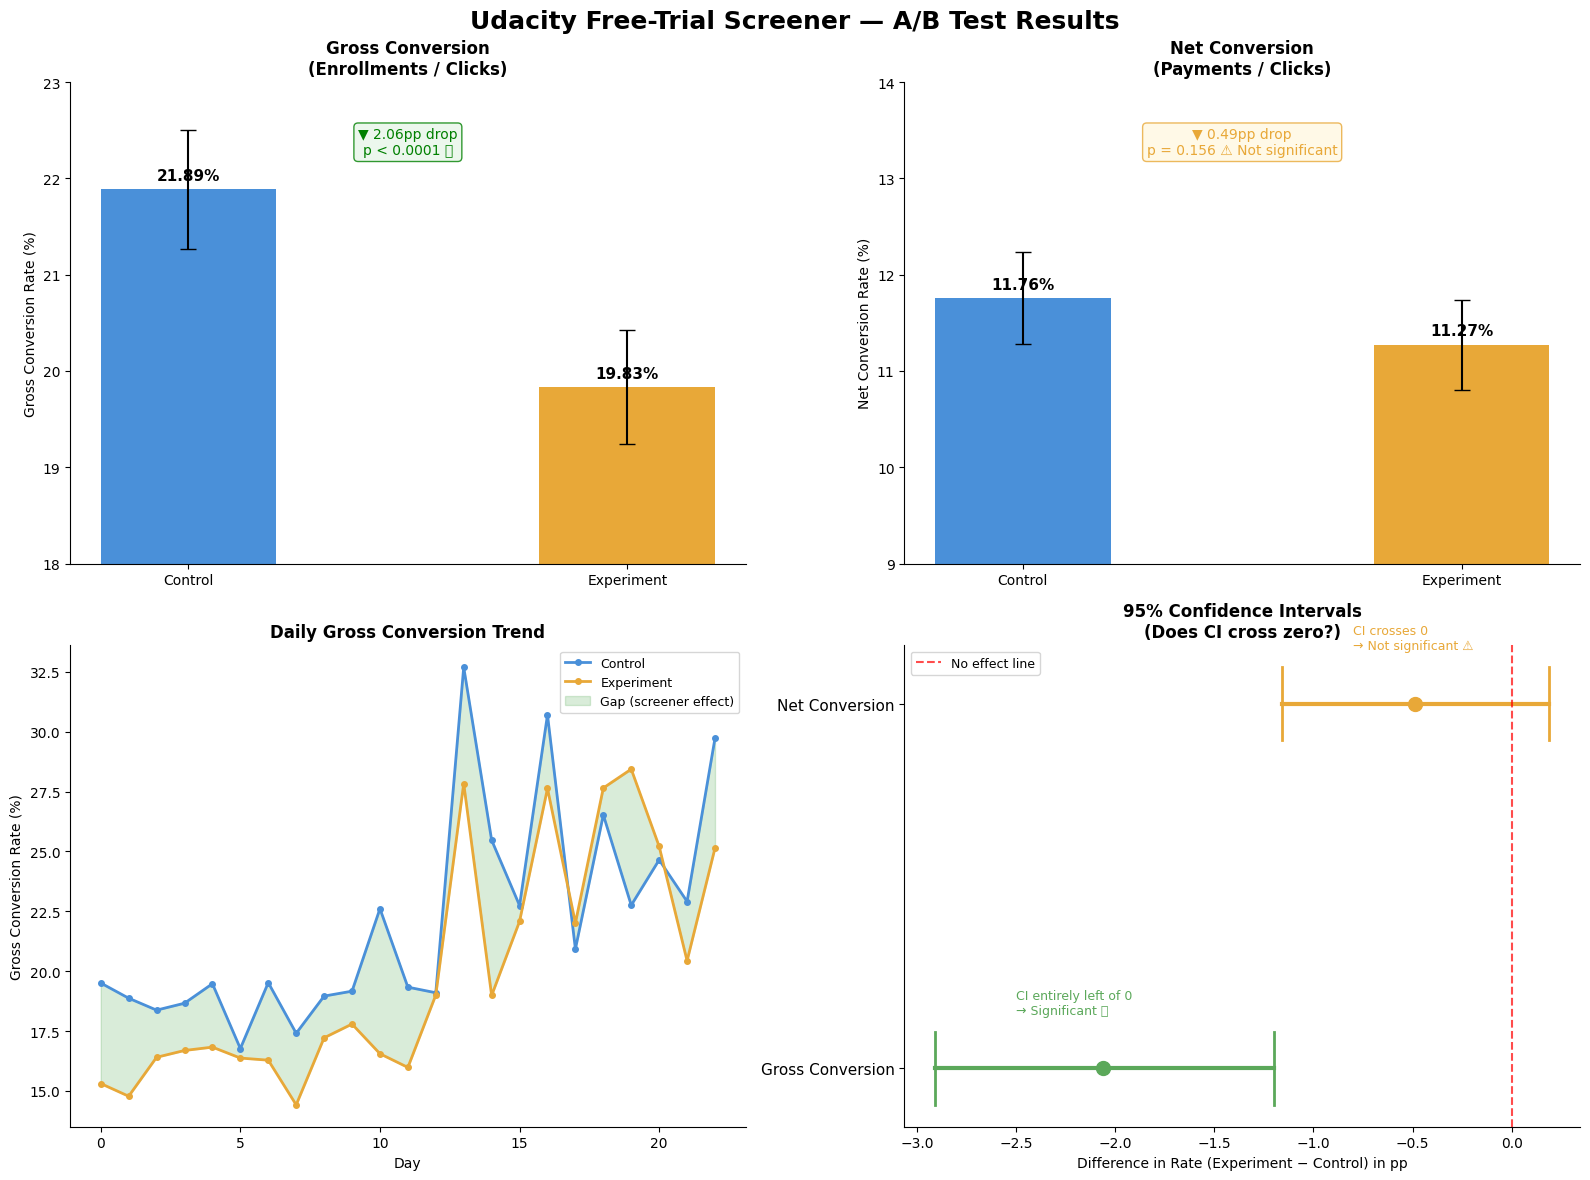

Chart saved as ab_test_results.png


In [5]:
#Step 5: Visualizations

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Udacity Free-Trial Screener — A/B Test Results', fontsize=18, fontweight='bold')

#Chart 1: Gross Conversion — Control vs Experiment
ax1 = axes[0, 0]
gc_control = ctrl_enroll / ctrl_clicks
gc_exp     = exp_enroll  / exp_clicks
gc_se_ctrl = np.sqrt(gc_control * (1 - gc_control) / ctrl_clicks)
gc_se_exp  = np.sqrt(gc_exp     * (1 - gc_exp)     / exp_clicks)

bars = ax1.bar(['Control', 'Experiment'],
               [gc_control * 100, gc_exp * 100],
               color=['#4A90D9', '#E8A838'], width=0.4,
               yerr=[gc_se_ctrl * 100 * 1.96, gc_se_exp * 100 * 1.96],
               capsize=6, error_kw={'linewidth': 1.5})

ax1.set_ylabel('Gross Conversion Rate (%)')
ax1.set_title('Gross Conversion\n(Enrollments / Clicks)', fontweight='bold')
ax1.set_ylim(18, 23)
ax1.spines[['top', 'right']].set_visible(False)

for bar, val in zip(bars, [gc_control * 100, gc_exp * 100]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')

ax1.annotate('▼ 2.06pp drop\np < 0.0001 ✅',
             xy=(0.5, 0.85), xycoords='axes fraction',
             ha='center', fontsize=10, color='green',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#e8f5e9', edgecolor='green', alpha=0.8))

#Chart 2: Net Conversion — Control vs Experiment
ax2 = axes[0, 1]
nc_control = ctrl_payments / ctrl_clicks
nc_exp     = exp_payments  / exp_clicks
nc_se_ctrl = np.sqrt(nc_control * (1 - nc_control) / ctrl_clicks)
nc_se_exp  = np.sqrt(nc_exp     * (1 - nc_exp)     / exp_clicks)

bars2 = ax2.bar(['Control', 'Experiment'],
                [nc_control * 100, nc_exp * 100],
                color=['#4A90D9', '#E8A838'], width=0.4,
                yerr=[nc_se_ctrl * 100 * 1.96, nc_se_exp * 100 * 1.96],
                capsize=6, error_kw={'linewidth': 1.5})

ax2.set_ylabel('Net Conversion Rate (%)')
ax2.set_title('Net Conversion\n(Payments / Clicks)', fontweight='bold')
ax2.set_ylim(9, 14)
ax2.spines[['top', 'right']].set_visible(False)

for bar, val in zip(bars2, [nc_control * 100, nc_exp * 100]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')

ax2.annotate('▼ 0.49pp drop\np = 0.156 ⚠️ Not significant',
             xy=(0.5, 0.85), xycoords='axes fraction',
             ha='center', fontsize=10, color='#E8A838',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff8e1', edgecolor='#E8A838', alpha=0.8))

#Chart 3: Daily Gross Conversion Trend
ax3 = axes[1, 0]
ctrl_clean_gc  = control_clean.copy()
exp_clean_gc   = experiment_clean.copy()

ctrl_clean_gc['gc']  = ctrl_clean_gc['Enrollments']  / ctrl_clean_gc['Clicks']
exp_clean_gc['gc']   = exp_clean_gc['Enrollments']   / exp_clean_gc['Clicks']

ax3.plot(range(len(ctrl_clean_gc)), ctrl_clean_gc['gc'] * 100,
         label='Control', color='#4A90D9', linewidth=2, marker='o', markersize=4)
ax3.plot(range(len(exp_clean_gc)),  exp_clean_gc['gc']  * 100,
         label='Experiment', color='#E8A838', linewidth=2, marker='o', markersize=4)

ax3.fill_between(range(len(ctrl_clean_gc)),
                 ctrl_clean_gc['gc'] * 100,
                 exp_clean_gc['gc']  * 100,
                 alpha=0.15, color='green', label='Gap (screener effect)')

ax3.set_xlabel('Day')
ax3.set_ylabel('Gross Conversion Rate (%)')
ax3.set_title('Daily Gross Conversion Trend', fontweight='bold')
ax3.legend(fontsize=9)
ax3.spines[['top', 'right']].set_visible(False)

#Chart 4: Confidence Interval Plot
ax4 = axes[1, 1]

metrics   = ['Gross Conversion', 'Net Conversion']
diffs     = [-0.0206, -0.0049]
ci_lowers = [-0.0291, -0.0116]
ci_uppers = [-0.0120,  0.0019]
colors    = ['#5BA85A', '#E8A838']

for i, (metric, diff, cil, ciu, color) in enumerate(zip(metrics, diffs, ci_lowers, ci_uppers, colors)):
    ax4.plot([cil * 100, ciu * 100], [i, i], color=color, linewidth=3)
    ax4.plot(diff * 100, i, 'o', color=color, markersize=10, zorder=5)
    ax4.plot([cil * 100, cil * 100], [i - 0.1, i + 0.1], color=color, linewidth=2)
    ax4.plot([ciu * 100, ciu * 100], [i - 0.1, i + 0.1], color=color, linewidth=2)

ax4.axvline(x=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='No effect line')
ax4.set_yticks([0, 1])
ax4.set_yticklabels(metrics, fontsize=11)
ax4.set_xlabel('Difference in Rate (Experiment − Control) in pp')
ax4.set_title('95% Confidence Intervals\n(Does CI cross zero?)', fontweight='bold')
ax4.legend(fontsize=9)
ax4.spines[['top', 'right']].set_visible(False)

ax4.text(-2.5, 0.15, 'CI entirely left of 0\n→ Significant ✅', fontsize=9, color='#5BA85A')
ax4.text(-0.8, 1.15, 'CI crosses 0\n→ Not significant ⚠️', fontsize=9, color='#E8A838')

plt.tight_layout()
plt.savefig('ab_test_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as ab_test_results.png")

In [7]:
doc = """
╔══════════════════════════════════════════════════════════════════════════════╗
║         UDACITY FREE-TRIAL SCREENER — A/B TEST RECOMMENDATION REPORT       ║
╚══════════════════════════════════════════════════════════════════════════════╝

ANALYST: [Your Name]
DATASET: Udacity A/B Test Final Project (Baseline + Control + Experiment)
PERIOD:  37 days | 23 days with complete enrollment/payment data
TOOLS:   Python (Pandas, NumPy, SciPy, Matplotlib), Google Colab

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. EXPERIMENT OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Change tested: A screener shown after clicking "Start Free Trial" asking
  students how many hours/week they can commit. Students committing <5 hrs
  are redirected to free course materials instead of enrolling.

  Hypothesis: Screener reduces low-intent enrollments without hurting revenue.

  Randomization unit: Cookie (unique visitor)
  Total traffic:      690,203 pageviews | 56,703 clicks
  Split:              50% control / 50% experiment

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. SANITY CHECKS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Pageviews split:   50.06% control  ✅ PASSED (95% CI: [0.4988, 0.5012])
  Clicks split:      50.05% control  ✅ PASSED (95% CI: [0.4959, 0.5041])

  Randomization is valid. Experiment data is clean to analyze.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3. RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  METRIC 1 — Gross Conversion (Enrollments / Clicks)
  ┌─────────────────┬───────────┬───────────┬──────────────────────────┐
  │                 │ Control   │ Experiment│ Result                   │
  ├─────────────────┼───────────┼───────────┼──────────────────────────┤
  │ Rate            │ 21.89%    │ 19.83%    │ ▼ 2.06pp drop            │
  │ 95% CI          │           │           │ [-0.0291, -0.0120]       │
  │ P-value         │           │           │ 0.0000                   │
  │ Significant     │           │           │ ✅ YES                   │
  │ Goal met        │           │           │ ✅ YES (decrease wanted) │
  └─────────────────┴───────────┴───────────┴──────────────────────────┘

  METRIC 2 — Net Conversion (Payments / Clicks)
  ┌─────────────────┬───────────┬───────────┬──────────────────────────┐
  │                 │ Control   │ Experiment│ Result                   │
  ├─────────────────┼───────────┼───────────┼──────────────────────────┤
  │ Rate            │ 11.76%    │ 11.27%    │ ▼ 0.49pp drop            │
  │ 95% CI          │           │           │ [-0.0116, 0.0019]        │
  │ P-value         │           │           │ 0.1558                   │
  │ Significant     │           │           │ ⚠️  NO (p = 0.156)       │
  │ Goal met        │           │           │ ⚠️  PARTIAL (CI touches 0│
  └─────────────────┴───────────┴───────────┴──────────────────────────┘

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
4. LAUNCH DECISION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Decision: ⚠️  CONDITIONAL LAUNCH — DO NOT SHIP WITHOUT MONITORING PLAN

  Reasoning:
  • Gross Conversion dropped 2.06pp (p < 0.0001) — screener is effectively
    filtering out low-intent students. This is working as designed.

  • Net Conversion dropped 0.49pp but is NOT statistically significant
    (p = 0.156). However the 95% CI [-0.0116, 0.0019] barely touches zero —
    meaning there is meaningful risk that revenue could be slightly hurt.

  • The experiment does NOT provide strong enough evidence that net revenue
    is fully protected. We cannot confidently say payments are unaffected.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5. RECOMMENDATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  REC 1 — Launch to 10% of traffic first with payment rate monitoring
  • Do not full-launch immediately given the Net Conversion uncertainty
  • Set a payment rate alert threshold at 11.0% — if it drops below,
    pause and investigate before expanding

  REC 2 — Extend experiment duration to increase statistical power
  • 23 days of enrollment data may be insufficient for Net Conversion
  • Running 4-6 more weeks would narrow the CI and give a clearer answer
    on whether the 0.49pp revenue drop is real or noise

  REC 3 — Segment results by student commitment level
  • Students who said 5+ hrs/week should be tracked separately
  • If their payment rate is significantly higher than the control baseline,
    that validates the screener's filtering logic and justifies launch

"""

print(doc)


╔══════════════════════════════════════════════════════════════════════════════╗
║         UDACITY FREE-TRIAL SCREENER — A/B TEST RECOMMENDATION REPORT       ║
╚══════════════════════════════════════════════════════════════════════════════╝

ANALYST: [Your Name]
DATASET: Udacity A/B Test Final Project (Baseline + Control + Experiment)
PERIOD:  37 days | 23 days with complete enrollment/payment data
TOOLS:   Python (Pandas, NumPy, SciPy, Matplotlib), Google Colab

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. EXPERIMENT OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Change tested: A screener shown after clicking "Start Free Trial" asking
  students how many hours/week they can commit. Students committing <5 hrs
  are redirected to free course materials instead of enrolling.

  Hypothesis: Screener reduces low-intent enrollments without hurting revenue.

  Randomization unit: Cookie (unique visitor)
  Total traf